# 0. Imports et Configuration

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

# Chemin vers le dataset NETTOYÉ (produit par run.py)
DATASET_CLEAN_PATH = Path("data/processed/dataset_fastia_clean_v1.jsonl")

# 1. Chargement des données

In [4]:
def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            obj = json.loads(line)
            rows.append({
                "input": obj.get("input", ""),
                "categorie": obj.get("output", {}).get("categorie", ""),
                "priorite": obj.get("output", {}).get("priorite", ""),
                "reponse_suggeree": obj.get("output", {}).get("reponse_suggeree", ""),
            })
    return pd.DataFrame(rows)


df = load_jsonl(DATASET_CLEAN_PATH)
print(f"Nombre d'exemples : {len(df)}")
df.head()

Nombre d'exemples : 96


,input,categorie,priorite,reponse_suggeree
0,"Bonjour, notre application de gestion RH plante depuis ce matin, impossible de se connecter. Toute l'équipe est bloq...",Support technique,haute,Nous prenons en charge votre incident en priorité. Notre équipe technique est mobilisée et reviendra vers vous dans ...
1,"Le serveur de production est tombé il y a 30 minutes, nos clients ne peuvent plus accéder au service.",Support technique,haute,Incident critique enregistré. Nous escaladons immédiatement auprès de notre équipe infrastructure. Un point de situa...
2,"Depuis la dernière mise à jour, les exports PDF ne fonctionnent plus correctement, les tableaux sont tronqués.",Support technique,haute,"Nous avons identifié un problème lié à la dernière mise à jour. Un correctif est en cours de déploiement, vous serez..."
3,"Notre pipeline de données s'est arrêté cette nuit, les rapports du matin sont vides.",Support technique,haute,Incident enregistré sur votre pipeline de données. Notre équipe data est alertée et analyse les logs. Un retour sous...
4,"URGENT : faille de sécurité détectée sur notre API exposée, des données clients pourraient être compromises.",Support technique,haute,Nous traitons cet incident de sécurité en priorité absolue. L'API sera isolée dans les plus brefs délais. Notre équi...


# 2. Biais de représentation
Distribution catégorie × priorité, identification des combinaisons sous-représentées

priorite                   haute  normale
categorie                                
Demande commerciale            7       11
Demande de transformation      7       10
Information générale           0       22
Réclamation                    7       10
Support technique              7       15


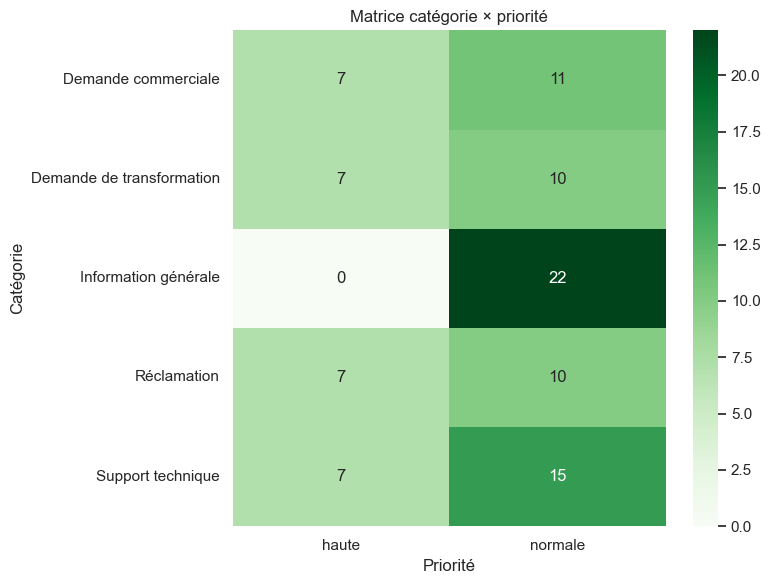

In [6]:
crosstab = pd.crosstab(df["categorie"], df["priorite"])
print(crosstab)
plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Greens")
plt.title("Matrice catégorie × priorité")
plt.xlabel("Priorité")
plt.ylabel("Catégorie")
plt.tight_layout()

Analyse des chiffres :

**Observation majeure** : La catégorie "Information générale" est la seule à n'avoir aucune occurrence en priorité "haute" (0 vs 22 en normale).

**Équilibre relatif** : Les autres catégories (Commercial, Transformation, Réclamation, Support) sont très équilibrées (environ 7 hautes pour 10-15 normales).

**Risque** : Le modèle risque de créer un lien statistique fort : "Si c'est une demande d'info, alors ce n'est jamais urgent".

**Stratégie d'atténuation** : Créer 5 à 10 exemples d'informations générales avec une priorité "haute".

# 3. Biais linguistique (Longueur et Registre)
Analyse : Existe-t-il une corrélation entre la longueur du texte et la catégorie ?

       len_input_chars  len_input_words  len_reponse_chars
count             96.0             96.0               96.0
mean              98.1             15.5              158.0
std               20.9              3.6               16.1
min               44.0              7.0              128.0
25%               84.8             12.8              147.0
50%               95.0             16.0              155.0
75%              113.2             18.0              167.8
max              141.0             26.0              200.0


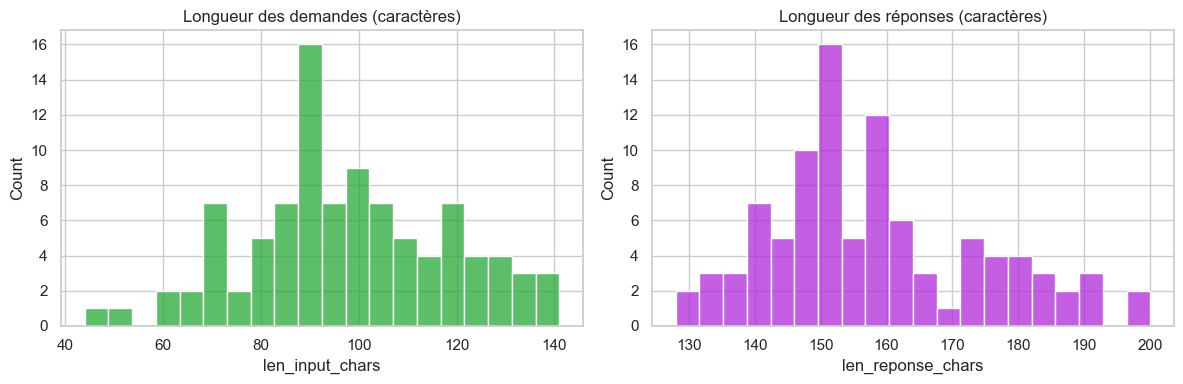

In [12]:
df["len_input_chars"] = df["input"].str.len()
df["len_reponse_chars"] = df["reponse_suggeree"].str.len()
df["len_input_words"] = df["input"].str.split().map(len)

print(df[["len_input_chars", "len_input_words", "len_reponse_chars"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["len_input_chars"], bins=20, ax=axes[0], color="#25a836")
axes[0].set_title("Longueur des demandes (caractères)")
sns.histplot(df["len_reponse_chars"], bins=20, ax=axes[1], color="#b028d9")
axes[1].set_title("Longueur des réponses (caractères)")
plt.tight_layout()

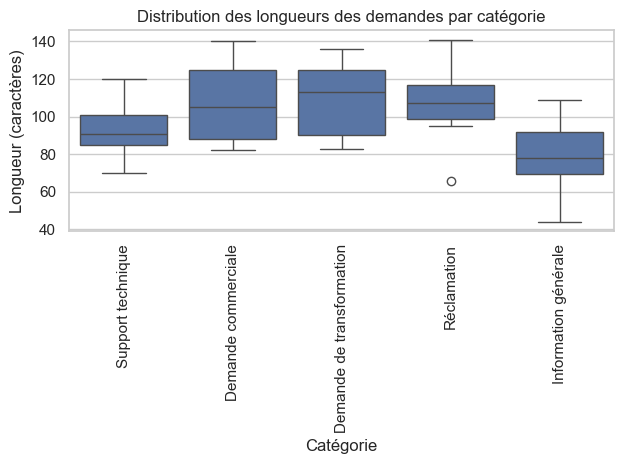

In [13]:
sns.boxplot(data=df, x="categorie", y="len_input_chars")
plt.title("Distribution des longueurs des demandes par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Longueur (caractères)")
plt.xticks(rotation=90)
plt.tight_layout()

**Observation** : La catégorie "Information générale" est celle qui présente le plus fort risque de biais lié à la longueur
Elle possède la médiane la plus basse (environ 75-80 caractères) et sa boîte (l'écart interquartile) ne chevauche quasiment pas celles des autres catégories
Conséquence : le modèle risque de prédire "Information générale" en se basant principalement sur la longueur de la demande plutôt que sur son contenu.

**Stratégie d'atténuation** : ajouter des exemples de la catégorie "Information générale" plus variés en longueur.


# 4 Biais de réponse (Style et Formulations)
le champ reponse_suggeree reproduit-il un style uniforme par catégorie ? Y a-t-il des formulations qui pourraient être perçues comme condescendantes ou dégradantes pour certains segments ?

In [8]:
# Recherche de motifs "froids" ou répétitifs
patterns_bias = ["évidemment", "comme déjà dit", "veuillez lire", "il suffit de"]
mask = df['reponse_suggeree'].str.contains('|'.join(patterns_bias), case=False, na=False)
flagged_responses = df[mask]

print(f"Nombre de réponses suspectes : {len(flagged_responses)}")

Nombre de réponses suspectes : 0


# 5 Données sensibles

In [10]:
PII_PATTERNS = {
    "email":     re.compile(r"[\w\.-]+@[\w\.-]+\.\w+"),
    "telephone": re.compile(r"(?:(?:\+33|0)\s?[1-9])(?:[\s.-]?\d{2}){4}"),
    "url":       re.compile(r"https?://\S+"),
    "ip":        re.compile(r"\b(?:\d{1,3}\.){3}\d{1,3}\b"),
}

input_pii_counts = {k: df["input"].str.contains(p, regex=True).sum() for k, p in PII_PATTERNS.items()}
input_pii_counts["total_lignes"] = len(df)
print(f"Comptage des PII dans l'entrée : {input_pii_counts}")

output_pii_counts = {k: df["reponse_suggeree"].str.contains(p, regex=True).sum() for k, p in PII_PATTERNS.items()}
output_pii_counts["total_lignes"] = len(df)
print(f"Comptage des PII dans la réponse suggérée : {output_pii_counts}")

Comptage des PII dans l'entrée : {'email': np.int64(0), 'telephone': np.int64(0), 'url': np.int64(0), 'ip': np.int64(0), 'total_lignes': 96}
Comptage des PII dans la réponse suggérée : {'email': np.int64(0), 'telephone': np.int64(0), 'url': np.int64(0), 'ip': np.int64(0), 'total_lignes': 96}
